1. Load Dataset
        │
        ▼
2. Understand the Data
        │
        ▼
3. Exploratory Data Analysis (EDA)
        │
        ▼
4. Data Preprocessing
        │
        ▼
5. Feature Engineering (if needed)
        │
        ▼
6. Split Train Data
        │
        ▼
7. training  Model
        │
        ▼
8. Evaluate Model
        │
        ▼
9. Improve the Model
        │
        ▼
10. Train on Full Training Data
        │
        ▼
11. Predict Test Data
        │
        ▼
12. Create Submission File
        │
        ▼
13. Upload to Kaggle

In [78]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.metrics import accuracy_score

1. LOAD DATASET

In [79]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
sample = pd.read_csv("sample_submission.csv")

2 UNDERSTAND THE DATA

In [80]:
train.head()

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male


In [81]:
train.tail()

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
690083,690083,at-risk,6.31,69.7,24.11,2157.0,NaN,30.8,3.00,non-veg,high,poor,active,yes,female
690084,690084,at-risk,5.78,54.0,26.36,2858.0,6488.0,52.4,1.46,veg,medium,average,moderate,no,male
690085,690085,fit,7.64,85.7,21.91,2195.0,9241.0,41.3,1.57,non-veg,NaN,average,active,no,male
690086,690086,at-risk,6.74,73.0,18.73,2061.0,13366.0,56.6,2.60,balanced,NaN,average,active,yes,male
690087,690087,at-risk,5.55,69.3,24.38,2257.0,5144.0,47.9,1.76,balanced,medium,average,moderate,yes,male


In [82]:
train.shape

(690088, 15)

In [83]:
train.columns

Index(['id', 'health_condition', 'sleep_duration', 'heart_rate', 'bmi',
       'calorie_expenditure', 'step_count', 'exercise_duration',
       'water_intake', 'diet_type', 'stress_level', 'sleep_quality',
       'physical_activity_level', 'smoking_alcohol', 'gender'],
      dtype='str')

In [84]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 690088 entries, 0 to 690087
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       690088 non-null  int64  
 1   health_condition         690088 non-null  str    
 2   sleep_duration           614089 non-null  float64
 3   heart_rate               682255 non-null  float64
 4   bmi                      676190 non-null  float64
 5   calorie_expenditure      637235 non-null  float64
 6   step_count               676172 non-null  float64
 7   exercise_duration        683187 non-null  float64
 8   water_intake             646611 non-null  float64
 9   diet_type                683187 non-null  str    
 10  stress_level             607277 non-null  str    
 11  sleep_quality            631757 non-null  str    
 12  physical_activity_level  653467 non-null  str    
 13  smoking_alcohol          661506 non-null  str    
 14  gender         

In [85]:
train.describe

<bound method NDFrame.describe of             id health_condition  sleep_duration  heart_rate    bmi  \
0            0        unhealthy            5.22        70.6  25.66   
1            1          at-risk            5.53        71.3  25.84   
2            2        unhealthy            5.29        75.4  24.54   
3            3        unhealthy            4.70        77.2  23.13   
4            4          at-risk            7.23        73.4  28.44   
...        ...              ...             ...         ...    ...   
690083  690083          at-risk            6.31        69.7  24.11   
690084  690084          at-risk            5.78        54.0  26.36   
690085  690085              fit            7.64        85.7  21.91   
690086  690086          at-risk            6.74        73.0  18.73   
690087  690087          at-risk            5.55        69.3  24.38   

        calorie_expenditure  step_count  exercise_duration  water_intake  \
0                    2174.0      1326.0          

3    EDA

In [86]:



cat_cols = train.select_dtypes(include="str").columns
cat_cols

Index(['health_condition', 'diet_type', 'stress_level', 'sleep_quality',
       'physical_activity_level', 'smoking_alcohol', 'gender'],
      dtype='str')

In [87]:
num_cols = train.select_dtypes(include=['int64', 'float64']).columns
num_cols

Index(['id', 'sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure',
       'step_count', 'exercise_duration', 'water_intake'],
      dtype='str')

In [88]:
#MISSING VALUES

In [89]:
train.isnull().sum()



id                             0
health_condition               0
sleep_duration             75999
heart_rate                  7833
bmi                        13898
calorie_expenditure        52853
step_count                 13916
exercise_duration           6901
water_intake               43477
diet_type                   6901
stress_level               82811
sleep_quality              58331
physical_activity_level    36621
smoking_alcohol            28582
gender                     21373
dtype: int64

In [90]:
#CHECK THE DISTRIBUTION OF OUTPUT COLUMN
train["health_condition"].value_counts()

health_condition
at-risk      592561
unhealthy     57724
fit           39803
Name: count, dtype: int64

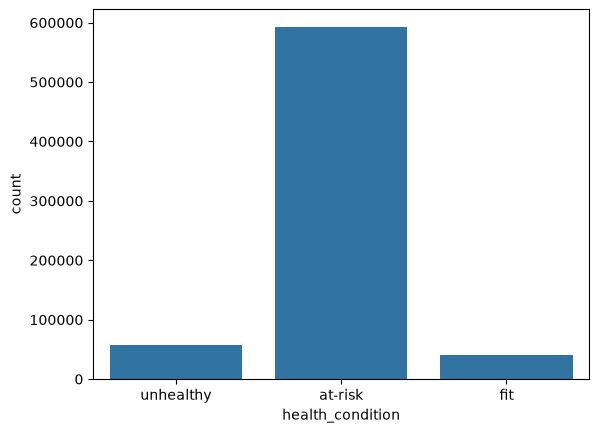

In [91]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=train, x="health_condition")
plt.show()

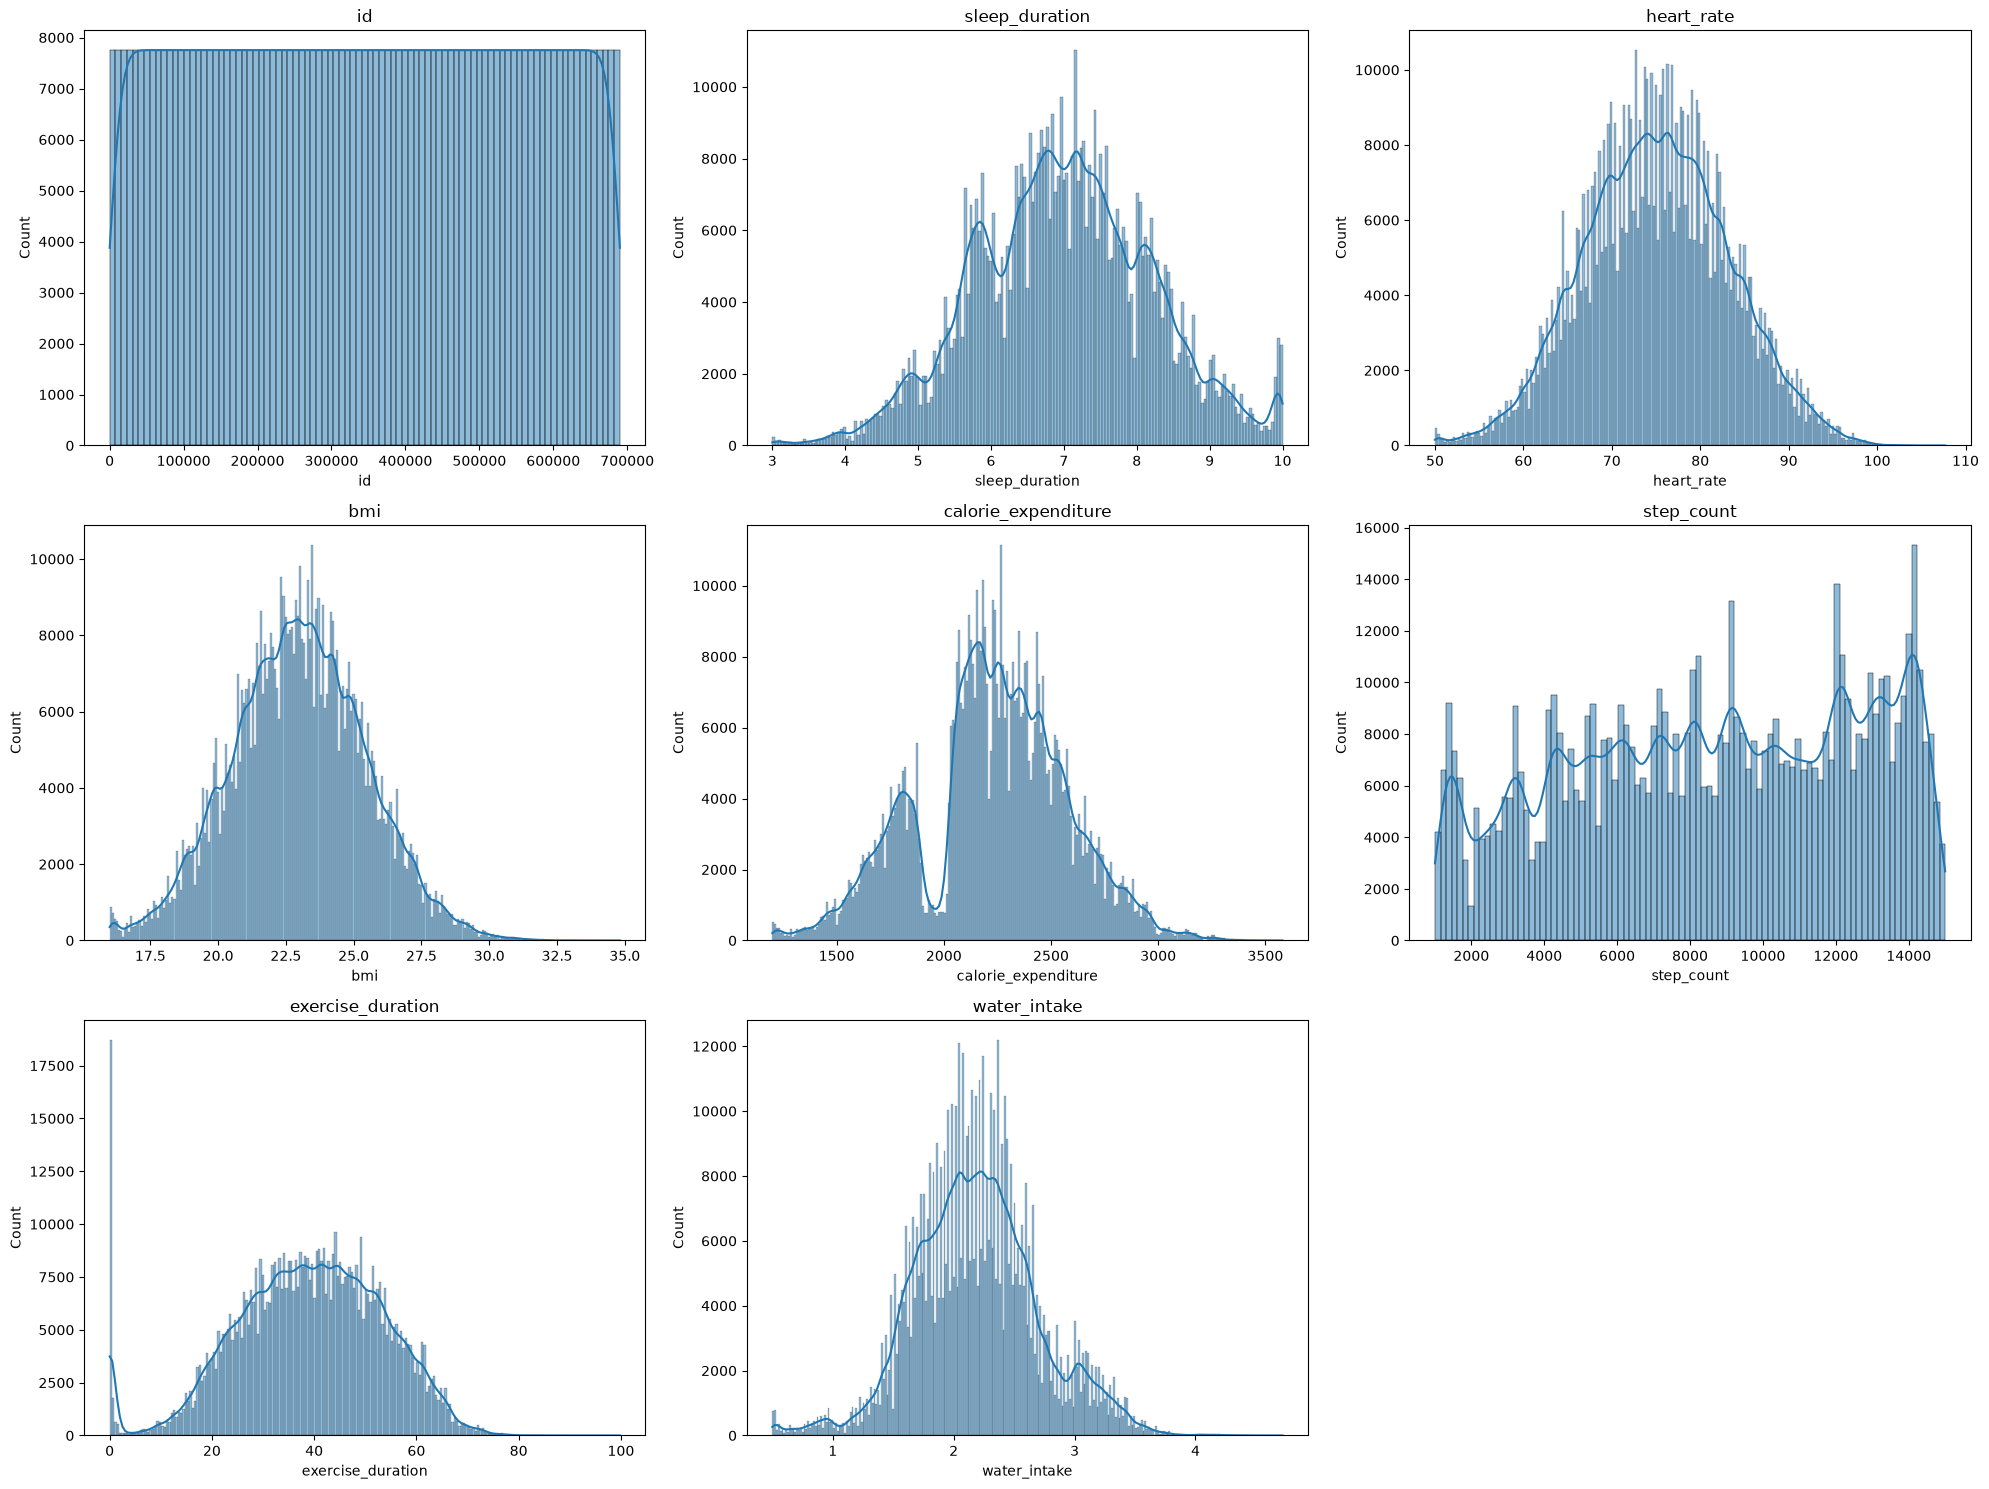

In [92]:
# NUMERICAL COLUMN ANALYSIS

import matplotlib.pyplot as plt
import seaborn as sns



plt.figure(figsize=(20, 15))

for i, col in enumerate(num_cols, 1):
    plt.subplot((len(num_cols)+2)//3, 3, i)
    sns.histplot(train[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()


In [93]:
train.describe()

,id,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake
count,690088.00000,614089.000000,682255.000000,676190.000000,637235.000000,676172.000000,683187.000000,646611.000000
mean,345043.50000,6.992597,75.096504,22.984925,2226.084931,8615.953050,38.751456,2.188542
std,199211.39062,1.215407,8.175106,2.481787,347.532098,3929.399831,14.742189,0.518489
min,0.00000,3.000000,50.000000,16.000000,1200.000000,1002.000000,0.000000,0.500000
25%,172521.75000,6.160000,69.400000,21.320000,2053.000000,5389.000000,29.200000,1.840000
50%,345043.50000,6.990000,75.100000,22.990000,2241.000000,8856.000000,39.400000,2.170000
75%,517565.25000,7.810000,80.700000,24.660000,2456.000000,12114.000000,49.400000,2.500000
max,690087.00000,10.000000,107.700000,34.820000,3580.000000,14999.000000,99.800000,4.720000


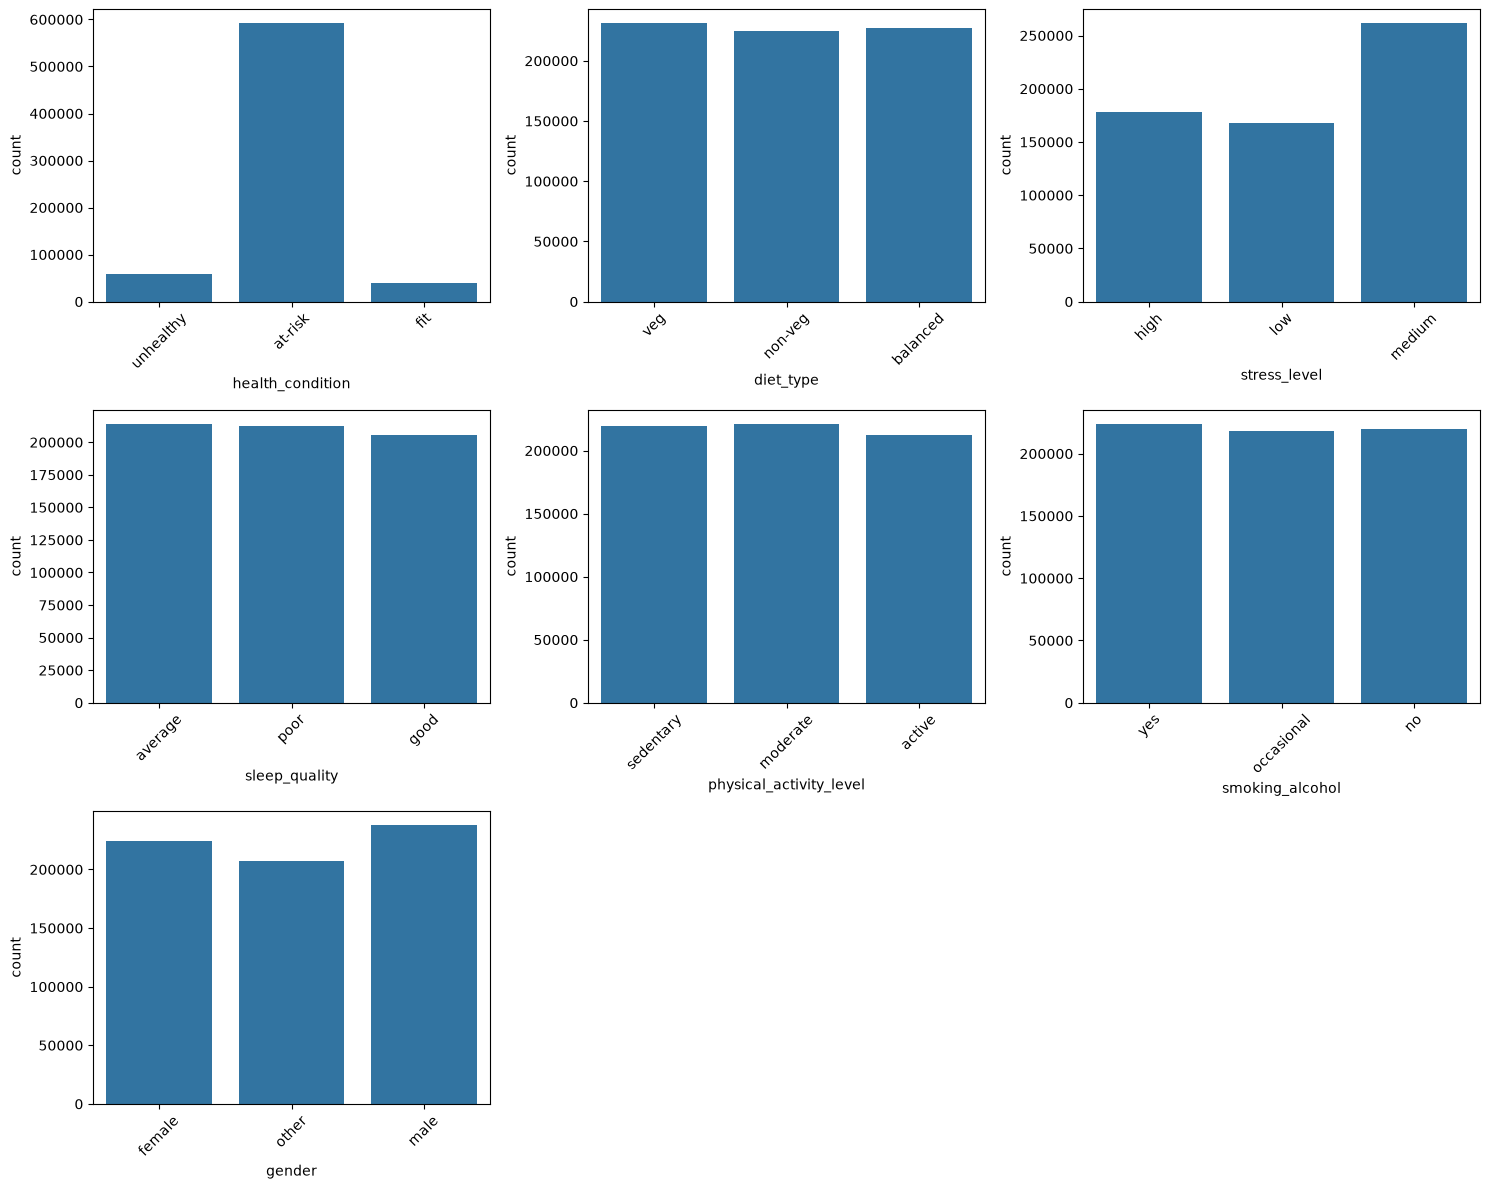

In [94]:
#ANALYSIS OF CAT COLUMNS


plt.figure(figsize=(15,12))

for i, col in enumerate(cat_cols, 1):
    plt.subplot((len(cat_cols)+2)//3, 3, i)
    sns.countplot(data=train, x=col)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

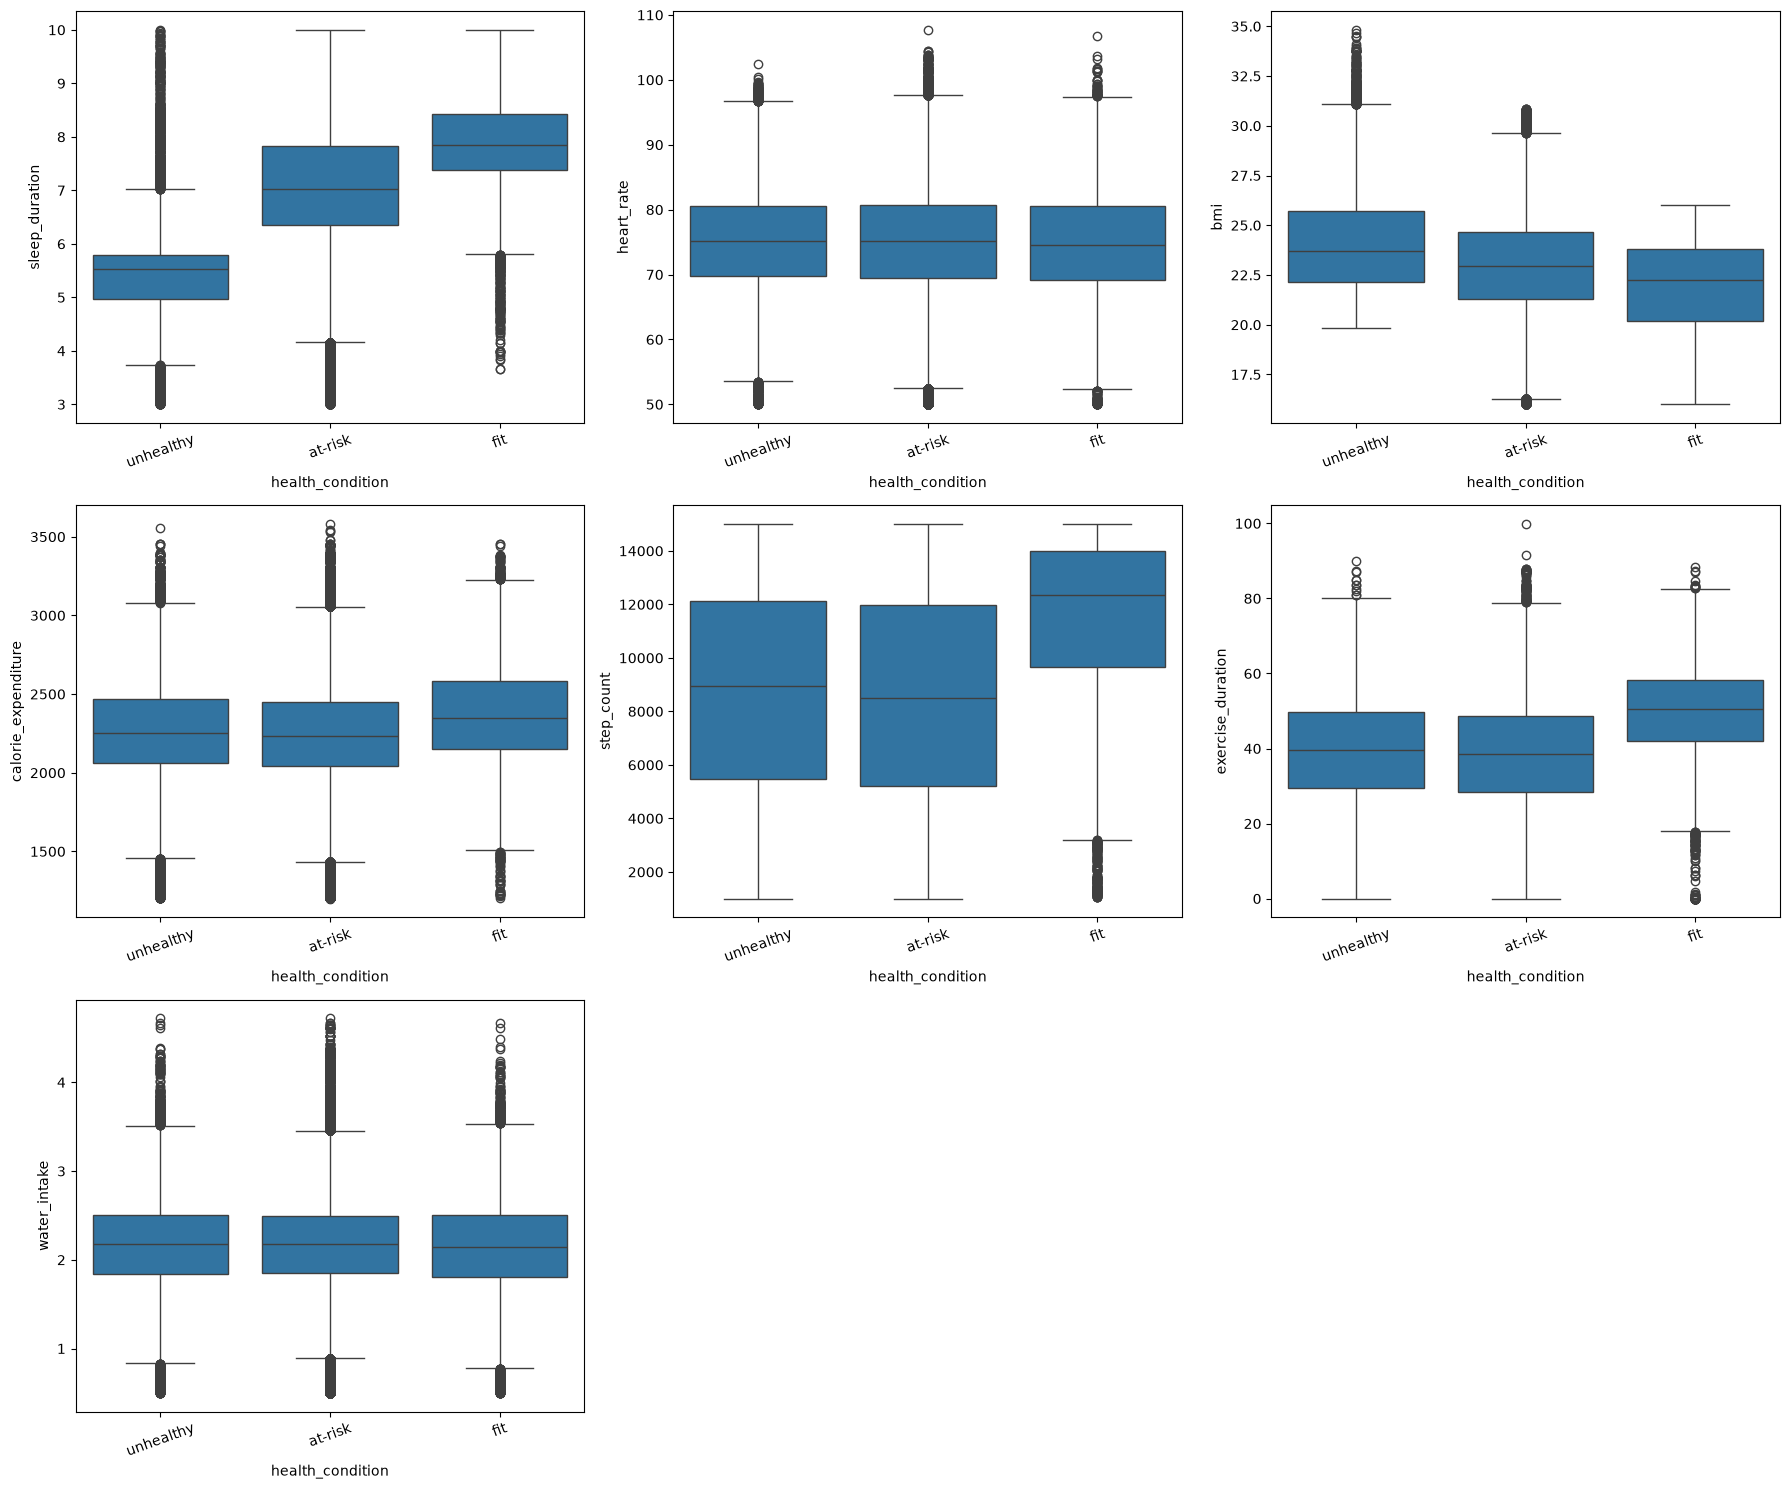

In [95]:


# Remove ID because it's not a useful feature

# NUM VS health COLN BOXPLOT 
num_cols = num_cols.drop('id')

plt.figure(figsize=(18,15))

for i, col in enumerate(num_cols, 1):
    plt.subplot((len(num_cols)+2)//3, 3, i)

    sns.boxplot(data=train,
                x='health_condition',
                y=col)

    plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

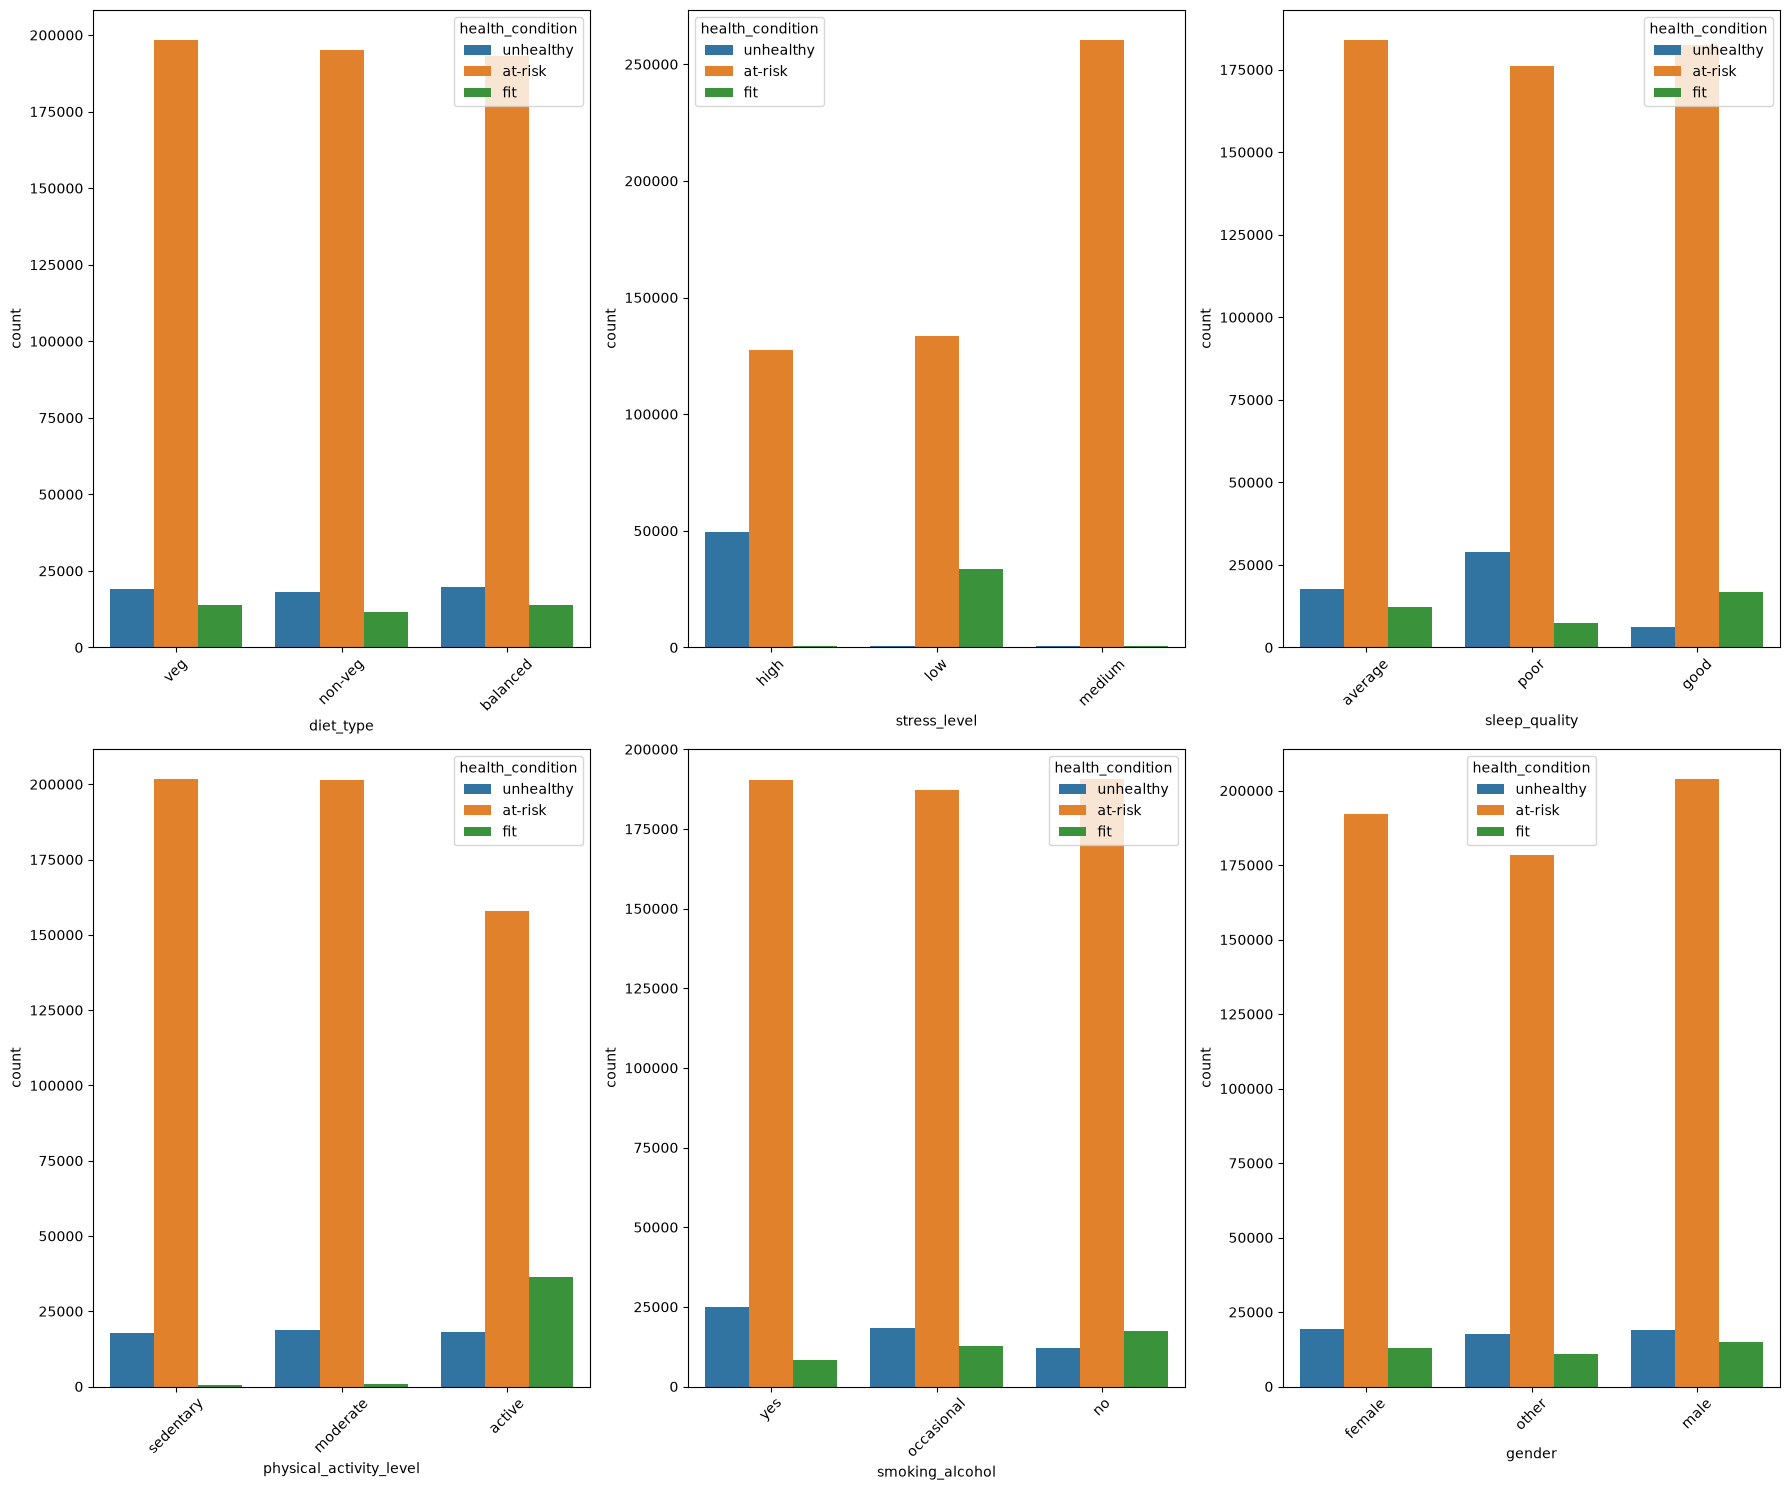

In [96]:
#Categorical Features vs Target Variable
cat_cols = cat_cols.drop("health_condition")

plt.figure(figsize=(18, 15))

for i, col in enumerate(cat_cols, 1):
    plt.subplot((len(cat_cols)+2)//3, 3, i)
    sns.countplot(data=train, x=col, hue="health_condition")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

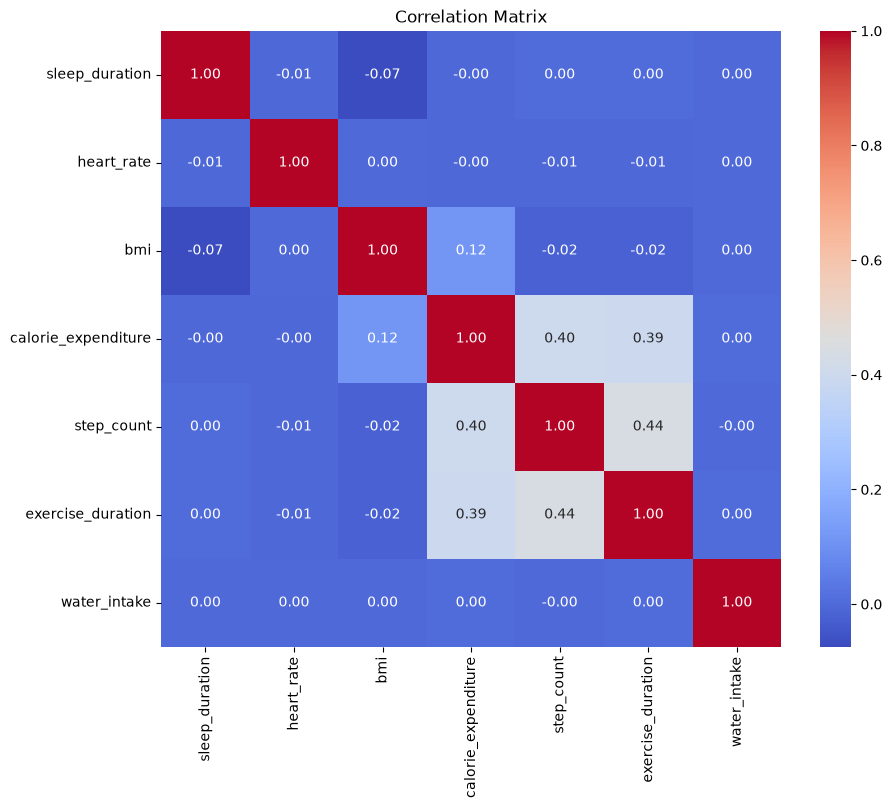

In [97]:
# MAKE CORRELATION MATRIX TO FIND CORRELATION AMONG COLUMNS
plt.figure(figsize=(10,8))

corr = train[num_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

4  DATA PREPROCESSING

In [98]:
 
print(train.isnull().sum())


id                             0
health_condition               0
sleep_duration             75999
heart_rate                  7833
bmi                        13898
calorie_expenditure        52853
step_count                 13916
exercise_duration           6901
water_intake               43477
diet_type                   6901
stress_level               82811
sleep_quality              58331
physical_activity_level    36621
smoking_alcohol            28582
gender                     21373
dtype: int64


In [99]:
print(test.isnull().sum())

id                             0
sleep_duration             32571
heart_rate                  3357
bmi                         5956
calorie_expenditure        22652
step_count                  5964
exercise_duration           2958
water_intake               18633
diet_type                   2958
stress_level               35490
sleep_quality              24999
physical_activity_level    15695
smoking_alcohol            12249
gender                      9160
dtype: int64


In [100]:


train[num_cols].skew()

sleep_duration        -0.008232
heart_rate             0.000438
bmi                    0.024640
calorie_expenditure   -0.183940
step_count            -0.180238
exercise_duration     -0.374610
water_intake           0.109960
dtype: float64

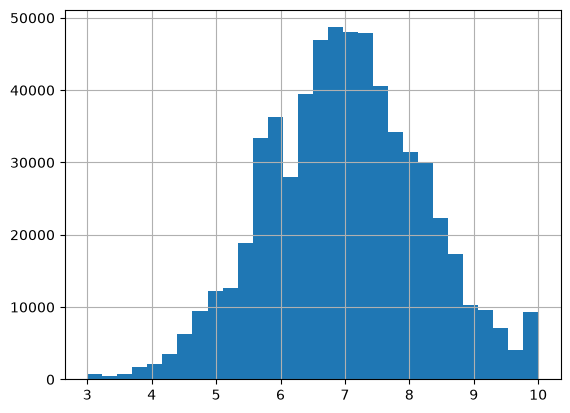

-0.008232338998971215


In [101]:
#HANDLING MISSING VALUES IN NUMERICAL COLUMN
#SLEEP DURATION
#| Data Type                                    | Distribution                               | Imputation |
#| -------------------------------------------- | ------------------------------------------ | ---------- |
#| Numerical                                    | Normal (Skewness between **-0.5 and 0.5**) | ✅ Mean     |
#| Numerical                                    | APPROX NORMAL OR Skewed or Outliers                         | ✅ Median   |
#| Categorical (`object`, `string`, `category`) | Any distribution                           | ✅ Mode     |

train['sleep_duration'].hist(bins=30)
plt.show()
print(train['sleep_duration'].skew()) 

In [102]:
# Approximately Normal Distribution -> Fill with mean value
mean_sleep = train["sleep_duration"].median()

train['sleep_duration'] = train['sleep_duration'].fillna(mean_sleep)
test['sleep_duration'] = test['sleep_duration'].fillna(mean_sleep)

In [103]:
# HEART RATE

print(train['heart_rate'].isnull().sum())
print(test['heart_rate'].isnull().sum())



7833
3357


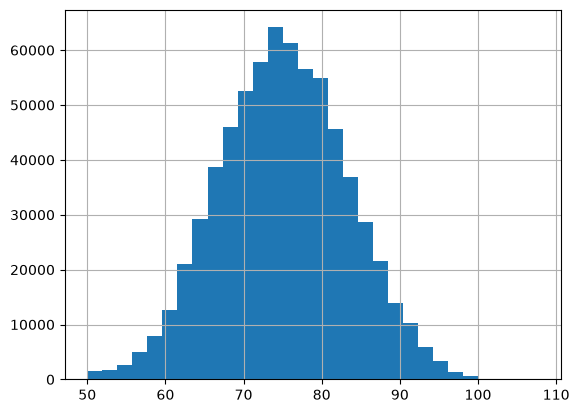

0.0004382013061315501


In [104]:
train['heart_rate'].hist(bins=30)
plt.show()
print(train['heart_rate'].skew()) 

In [105]:
# Approximately Normal Distribution -> Fill with mean value
mean_hr = train['heart_rate'].median()

train['heart_rate'] = train['heart_rate'].fillna(mean_hr)
test['heart_rate'] = test['heart_rate'].fillna(mean_hr)

In [106]:
#BMI

print(train['bmi'].isnull().sum())
print(test['bmi'].isnull().sum())


13898
5956


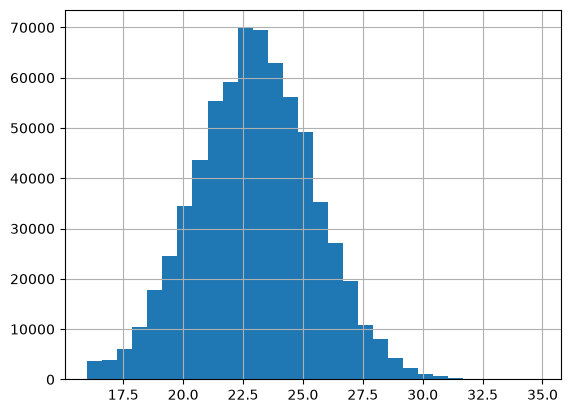

0.024639760001971284


In [107]:
train['bmi'].hist(bins=30)
plt.show()
print(train['bmi'].skew()) 

In [108]:
# Approximately Normal Distribution -> Fill with mean value
mean_bmi = train["bmi"].median()

train["bmi"] = train["bmi"].fillna(mean_bmi)
test["bmi"] = test["bmi"].fillna(mean_bmi)

In [109]:
#CALORIE_EXPENDITURE
print(train['calorie_expenditure'].isnull().sum())
print(test['calorie_expenditure'].isnull().sum())

52853
22652


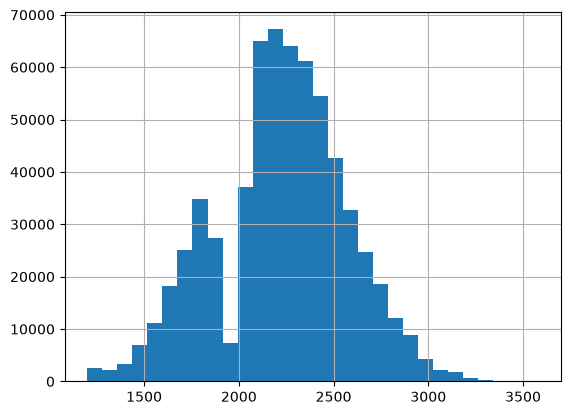

-0.1839399892368626


In [110]:
train['calorie_expenditure'].hist(bins=30)
plt.show()
print(train['calorie_expenditure'].skew()) 

In [111]:
# Approximately Normal Distribution -> Fill with mean value
mean_cal = train["calorie_expenditure"].median()

train["calorie_expenditure"] = train["calorie_expenditure"].fillna(mean_cal)
test["calorie_expenditure"] = test["calorie_expenditure"].fillna(mean_cal)

In [112]:
#STEP_COUNT
print(train['step_count'].isnull().sum())
print(test['step_count'].isnull().sum())


13916
5964


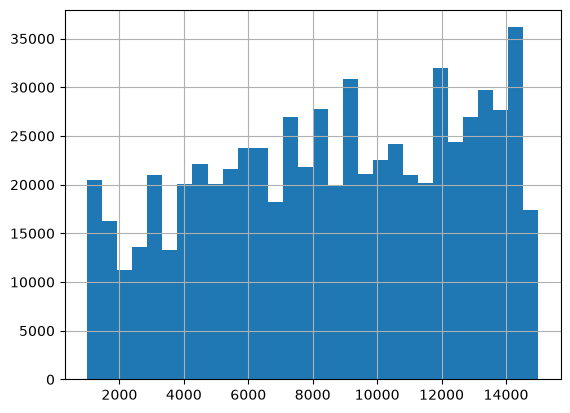

-0.1802384360383271


In [113]:
train['step_count'].hist(bins=30)
plt.show()
print(train['step_count'].skew()) 

In [114]:
# Approximately Normal Distribution -> Fill with mean value
mean_step_count = train["step_count"].median()

train["step_count"] = train["step_count"].fillna(mean_cal)
test["step_count"] = test["step_count"].fillna(mean_cal)

In [115]:
#exercise_duration
print(train['step_count'].isnull().sum())
print(test['step_count'].isnull().sum())

0
0


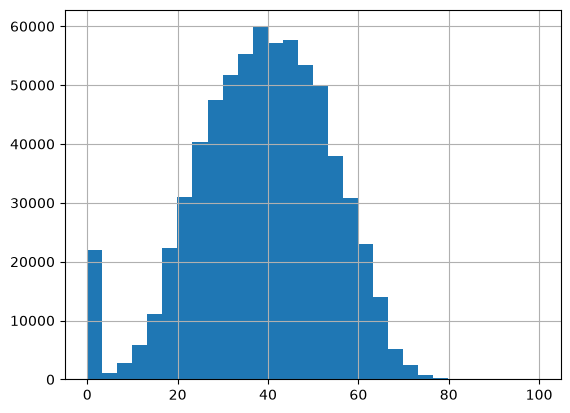

-0.3746098024470931


In [116]:


train['exercise_duration'].hist(bins=30)
plt.show()

print(train['exercise_duration'].skew()) 



In [117]:
# Approximately Normal Distribution -> Fill with mean value
mean_exercise_duration = train["exercise_duration"].median()

train["exercise_duration"] = train["exercise_duration"].fillna(mean_cal)
test["exercise_duration"] = test["exercise_duration"].fillna(mean_cal)

In [118]:
#water_intake
print(train['water_intake'].isnull().sum())
print(test['water_intake'].isnull().sum())


43477
18633


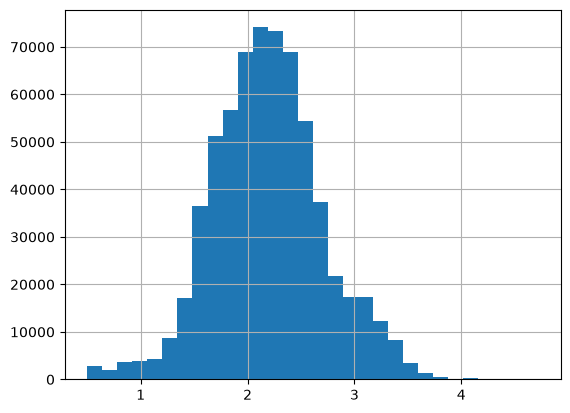

0.10996029570066407


In [119]:

train['water_intake'].hist(bins=30)
plt.show()

print(train['water_intake'].skew()) 


In [120]:
# Approximately Normal Distribution -> Fill with mean value
mean_water = train["water_intake"].median()

train["water_intake"] = train["water_intake"].fillna(mean_water)
test["water_intake"] = test["water_intake"].fillna(mean_water)

In [121]:

#handling missing values in categorical column

#diet type

print(train['diet_type'].isnull().sum())
print(test['diet_type'].isnull().sum())

6901
2958


In [122]:
train['diet_type'].value_counts(dropna=False)


diet_type
veg         231432
balanced    226888
non-veg     224867
NaN           6901
Name: count, dtype: int64

In [123]:
train.isnull().sum()

id                             0
health_condition               0
sleep_duration                 0
heart_rate                     0
bmi                            0
calorie_expenditure            0
step_count                     0
exercise_duration              0
water_intake                   0
diet_type                   6901
stress_level               82811
sleep_quality              58331
physical_activity_level    36621
smoking_alcohol            28582
gender                     21373
dtype: int64

In [124]:
# Approximately equally Distribution -> Fill with mode value
mode_diet = train["diet_type"].mode()[0]

train["diet_type"] = train["diet_type"].fillna(mode_diet)
test["diet_type"] = test["diet_type"].fillna(mode_diet)

In [125]:
#stress level

train['stress_level'].isnull().sum()


np.int64(82811)

In [126]:
train['stress_level'].value_counts(dropna=False)

stress_level
medium    261819
high      177750
low       167708
NaN        82811
Name: count, dtype: int64

In [127]:
# Approximately equally Distribution -> Fill with mode value

train["stress_level"] = train["stress_level"].fillna('Unknown')
test["stress_level"] = test["stress_level"].fillna('Unknown')

In [128]:
#sleep quality
train['sleep_quality'].isnull().sum()

np.int64(58331)

In [129]:
train['sleep_quality'].value_counts(dropna=False)

sleep_quality
average    213948
poor       212166
good       205643
NaN         58331
Name: count, dtype: int64

In [130]:
# Approximately equally Distribution -> Fill with mode value

train["sleep_quality"] = train["sleep_quality"].fillna('Unknown')
test["sleep_quality"] = test["sleep_quality"].fillna('Unknown')

In [131]:
#physical activity level
train['physical_activity_level'].isnull().sum()

np.int64(36621)

In [132]:
train['physical_activity_level'].value_counts(dropna=False)

physical_activity_level
moderate     221041
sedentary    219784
active       212642
NaN           36621
Name: count, dtype: int64

In [133]:
# Approximately equally Distribution -> Fill with mode value
mode_activity = train["physical_activity_level"].mode()[0]

train["physical_activity_level"] = train["physical_activity_level"].fillna(mode_activity)
test["physical_activity_level"] = test["physical_activity_level"].fillna(mode_activity)

In [134]:
#smoking alcohol
train['smoking_alcohol'].isnull().sum()


np.int64(28582)

In [135]:
train['smoking_alcohol'].value_counts(dropna=False)

smoking_alcohol
yes           223730
no            219791
occasional    217985
NaN            28582
Name: count, dtype: int64

In [136]:
# Approximately equally Distribution -> Fill with mode value
mode_smoking = train["smoking_alcohol"].mode()[0]

train["smoking_alcohol"] = train["smoking_alcohol"].fillna(mode_smoking)
test["smoking_alcohol"] = test["smoking_alcohol"].fillna(mode_smoking)

In [137]:
#gender
train['gender'].isnull().sum()

np.int64(21373)

In [138]:
train['gender'].value_counts(dropna=False)

gender
male      237756
female    224016
other     206943
NaN        21373
Name: count, dtype: int64

In [ ]:
# Approximately equally Distribution -> Fill with mode value
mode_gender = train["gender"].mode()[0]

train["gender"] = train["gender"].fillna(mode_gender)
test["gender"] = test["gender"].fillna(mode_gender)

5.FEATURE ENGINEERING

In [140]:
# Calories burned per step
train["calorie_per_step"] = train["calorie_expenditure"] / train["step_count"]
test["calorie_per_step"] = test["calorie_expenditure"] / test["step_count"]

In [141]:
# Water intake relative to BMI
train["water_per_bmi"] = train["water_intake"] / train["bmi"]
test["water_per_bmi"] = test["water_intake"] / test["bmi"]

In [142]:
# BMI Category
def bmi_category(x):
    if x < 18.5:
        return "Underweight"
    elif x < 25:
        return "Normal"
    elif x < 30:
        return "Overweight"
    else:
        return "Obese"

train["bmi_category"] = train["bmi"].apply(bmi_category)
test["bmi_category"] = test["bmi"].apply(bmi_category)

In [143]:
# Exercise Intensity
train["exercise_intensity"] = train["calorie_expenditure"] / (train["exercise_duration"] + 0.0001)
test["exercise_intensity"] = test["calorie_expenditure"] / (test["exercise_duration"] +0.0001)

In [144]:
# Steps Per Minutes
train["steps_per_minute"] = train["step_count"] / (train["exercise_duration"] + 1)
test["steps_per_minute"] = test["step_count"] / (test["exercise_duration"] + 1)

In [145]:
numerical_cols = [
    'sleep_duration',
    'heart_rate',
    'bmi',
    'calorie_expenditure',
    'step_count',
    'exercise_duration',
    'water_intake'
]

categorical_cols = [
    'diet_type',
    'stress_level',
    'sleep_quality',
    'physical_activity_level',
    'smoking_alcohol',
    'gender'
]

full = pd.concat(
    [
        train[numerical_cols + categorical_cols],
        test[numerical_cols + categorical_cols]
    ],
    axis=0,
    ignore_index=True
)
freq_features = []

for col in numerical_cols + categorical_cols:

    freq = full[col].value_counts()

    train[col + "_freq"] = train[col].map(freq)

    test[col + "_freq"] = test[col].map(freq)

    freq_features.append(col + "_freq")
numerical_cols = numerical_cols + freq_features

In [146]:
train.shape

(690088, 33)

6 SPLIT TRAIN DATA

In [147]:
# split features and target variable
X = train.drop(columns='health_condition')
y = train['health_condition']

In [148]:
# save id columns

train_id = train['id']
test_id = test['id']

X = train.drop(columns='id')
test = test.drop(columns='id')

In [149]:
# train test split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [150]:
from sklearn.preprocessing import OrdinalEncoder , StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix, balanced_accuracy_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report


In [151]:
numerical_columns = [
    'sleep_duration',
    'heart_rate',
    'bmi',
    'calorie_expenditure',
    'step_count',
    'exercise_duration',
    'water_intake',


    'calorie_per_step',
    'water_per_bmi',
    'exercise_intensity'
    'steps_per_minute'
    
    'sleep_duration_freq',
    'heart_rate_freq',
    'bmi_freq',
    'calorie_expenditure_freq',
    'step_count_freq',
    'exercise_duration_freq',
    'water_intake_freq',
    
    'diet_type_freq',
    'stress_level_freq',
    'sleep_quality_freq',
    'physical_activity_level_freq',
    'smoking_alcohol_freq',
    'gender_freq'
]

ordinal_columns = [
    'stress_level',
    'sleep_quality',
    'physical_activity_level',
    'bmi_category',
    
]

nominal_columns = [
    'diet_type',
    'smoking_alcohol',
    'gender'
]

In [152]:
# preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_cols
        ),

        (
            "ordinal",
            OrdinalEncoder(
                categories=[
                    ["low", "medium", "high"],
                    ["poor", "average", "good"],
                    ["sedentary", "moderate", "active"],
                    ["Underweight", "Normal", "Overweight", "Obese"]
                ]
            ),
            ordinal_columns
        ),

        (
            "nominal",
            OneHotEncoder(handle_unknown="ignore"),
            nominal_columns
        )
    ],
    remainder="drop"
)

7 TRAIN THE MODEL

In [153]:
result = []

In [154]:
#LOGISTIC REG.
pipe = Pipeline([
    ("preprocessor", preprocessor),

    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

pipe = pipe.fit(X_train,y_train)
y_pred = pipe.predict(X_test)

ValueError: Found unknown categories ['Unknown'] in column 0 during fit

In [ ]:
print("Balanced Accuracy :", balanced_accuracy_score(y_test, y_pred))
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average="weighted"))
print("Recall   :", recall_score(y_test, y_pred, average="weighted"))
print("F1 Score :", f1_score(y_test, y_pred, average="weighted"))
print("\nClassification Report")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

result.append({
    "Model": "LogisticRegression",
    "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, average="weighted"),
    "Recall": recall_score(y_test, y_pred, average="weighted"),
    "F1 Score": f1_score(y_test, y_pred, average="weighted"),
    "Macro F1": f1_score(y_test, y_pred, average="macro")
})

Balanced Accuracy : 0.8159700990786402
Accuracy : 0.9480212725876335
Precision: 0.946182906134196
Recall   : 0.9480212725876335
F1 Score : 0.9459383332234307

Classification Report
              precision    recall  f1-score   support

     at-risk       0.96      0.98      0.97    118512
         fit       0.87      0.74      0.80      7961
   unhealthy       0.89      0.72      0.79     11545

    accuracy                           0.95    138018
   macro avg       0.90      0.82      0.86    138018
weighted avg       0.95      0.95      0.95    138018


Confusion Matrix
[[116607    854   1051]
 [  2018   5919     24]
 [  3212     15   8318]]


In [ ]:
# preprocessor1 FOR DT,ADABOOOST,XGBOOST,RF
preprocessor1 = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_cols
        ),

        (
            "ordinal",
            OrdinalEncoder(
                categories=[
                    ["low", "medium", "high"],
                    ["poor", "average", "good"],
                    ["sedentary", "moderate", "active"],
                    ["Underweight", "Normal", "Overweight", "Obese"]
                ]
            ),
            ordinal_columns
        ),

        (
            "nominal",
            OneHotEncoder(handle_unknown="ignore"),
            nominal_columns
        )
    ],
    remainder="drop"
)

In [ ]:
from sklearn.tree import DecisionTreeClassifier


# Decision Tree 
pipe = Pipeline([
    ("preprocessor1", preprocessor1),

    ("model", DecisionTreeClassifier(
        random_state=42
    ))
])

pipe.fit(X_train, y_train)

y_pred = pipe.predict(X_test)

In [ ]:
print("Balanced Accuracy :", balanced_accuracy_score(y_test, y_pred))
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average="weighted"))
print("Recall   :", recall_score(y_test, y_pred, average="weighted"))
print("F1 Score :", f1_score(y_test, y_pred, average="weighted"))
print("\nClassification Report")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

result.append({
    "Model": "Decision Tree",
    "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, average="weighted"),
    "Recall": recall_score(y_test, y_pred, average="weighted"),
    "F1 Score": f1_score(y_test, y_pred, average="weighted"),
    "Macro F1": f1_score(y_test, y_pred, average="macro")
})

Balanced Accuracy : 0.8524337329040694
Accuracy : 0.9383341303308265
Precision: 0.9394725426242492
Recall   : 0.9383341303308265
F1 Score : 0.9388499402771001

Classification Report
              precision    recall  f1-score   support

     at-risk       0.97      0.96      0.96    118512
         fit       0.75      0.79      0.77      7961
   unhealthy       0.78      0.80      0.79     11545

    accuracy                           0.94    138018
   macro avg       0.83      0.85      0.84    138018
weighted avg       0.94      0.94      0.94    138018


Confusion Matrix
[[113920   2013   2579]
 [  1604   6307     50]
 [  2211     54   9280]]


In [ ]:
from sklearn.ensemble import RandomForestClassifier


# Random Forest 
pipe = Pipeline([
    ("preprocessor1", preprocessor1),

    ("model", RandomForestClassifier(
        n_estimators=20,
        random_state=42,
        n_jobs=-1
    ))
])

# Train Model
pipe.fit(X_train, y_train)

# Prediction
y_pred = pipe.predict(X_test)

In [ ]:
print("Balanced Accuracy :", balanced_accuracy_score(y_test, y_pred))
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average="weighted"))
print("Recall   :", recall_score(y_test, y_pred, average="weighted"))
print("F1 Score :", f1_score(y_test, y_pred, average="weighted"))
print("\nClassification Report")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

result.append({
    "Model": "RANDOM FOREST",
    "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, average="weighted"),
    "Recall": recall_score(y_test, y_pred, average="weighted"),
    "F1 Score": f1_score(y_test, y_pred, average="weighted"),
    "Macro F1": f1_score(y_test, y_pred, average="macro")
})


Balanced Accuracy : 0.8515330549462319
Accuracy : 0.9646422930342419
Precision: 0.9645835982116002
Recall   : 0.9646422930342419
F1 Score : 0.9630243488707033

Classification Report
              precision    recall  f1-score   support

     at-risk       0.96      1.00      0.98    118512
         fit       0.95      0.79      0.86      7961
   unhealthy       0.97      0.77      0.86     11545

    accuracy                           0.96    138018
   macro avg       0.96      0.85      0.90    138018
weighted avg       0.96      0.96      0.96    138018


Confusion Matrix
[[117960    282    270]
 [  1661   6272     28]
 [  2623     16   8906]]


In [ ]:
from sklearn.ensemble import AdaBoostClassifier
#ADABOOST
pipe = Pipeline([
    ("preprocessor1", preprocessor1),

    ("model", AdaBoostClassifier(
        n_estimators=100,
        learning_rate=1.0,
        random_state=42
    ))
])

pipe.fit(X_train, y_train)

y_pred = pipe.predict(X_test)

In [ ]:
print("Balanced Accuracy :", balanced_accuracy_score(y_test, y_pred))
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average="weighted"))
print("Recall   :", recall_score(y_test, y_pred, average="weighted"))
print("F1 Score :", f1_score(y_test, y_pred, average="weighted"))
print("\nClassification Report")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

result.append({
    "Model": "ADABOOST",
    "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, average="weighted"),
    "Recall": recall_score(y_test, y_pred, average="weighted"),
    "F1 Score": f1_score(y_test, y_pred, average="weighted"),
    "Macro F1": f1_score(y_test, y_pred, average="macro")
})


Balanced Accuracy : 0.6180148355504622
Accuracy : 0.9264226405251489
Precision: 0.9313643285785466
Recall   : 0.9264226405251489
F1 Score : 0.9061073145510726

Classification Report
              precision    recall  f1-score   support

     at-risk       0.92      1.00      0.96    118512
         fit       0.99      0.12      0.21      7961
   unhealthy       0.99      0.74      0.84     11545

    accuracy                           0.93    138018
   macro avg       0.97      0.62      0.67    138018
weighted avg       0.93      0.93      0.91    138018


Confusion Matrix
[[118410      7     95]
 [  7010    926     25]
 [  3018      0   8527]]


In [ ]:
from catboost import CatBoostClassifier


# CatBoost Pipeline
pipe = Pipeline([
    ("preprocessor1", preprocessor1),

    ("model", CatBoostClassifier(
        iterations=20,
        learning_rate=0.1,
        depth=6,
        random_state=42,
        verbose=0
    ))
])

pipe.fit(X_train, y_train)

y_pred = pipe.predict(X_test)

In [ ]:
print("Balanced Accuracy :", balanced_accuracy_score(y_test, y_pred))
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average="weighted"))
print("Recall   :", recall_score(y_test, y_pred, average="weighted"))
print("F1 Score :", f1_score(y_test, y_pred, average="weighted"))
print("\nClassification Report")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

result.append({
    "Model": "CATBOOST",
    "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, average="weighted"),
    "Recall": recall_score(y_test, y_pred, average="weighted"),
    "F1 Score": f1_score(y_test, y_pred, average="weighted"),
    "Macro F1": f1_score(y_test, y_pred, average="macro")
})


Balanced Accuracy : 0.8449651504648981
Accuracy : 0.9627294990508485
Precision: 0.9629175334952615
Recall   : 0.9627294990508485
F1 Score : 0.9609170496252942

Classification Report
              precision    recall  f1-score   support

     at-risk       0.96      1.00      0.98    118512
         fit       0.92      0.79      0.85      7961
   unhealthy       0.99      0.75      0.85     11545

    accuracy                           0.96    138018
   macro avg       0.96      0.84      0.89    138018
weighted avg       0.96      0.96      0.96    138018


Confusion Matrix
[[117935    510     67]
 [  1627   6303     31]
 [  2887     22   8636]]


In [ ]:
from lightgbm import LGBMClassifier


# LightGBM Pipeline
pipe = Pipeline([
    ("preprocessor", preprocessor),

    ("model", LGBMClassifier(
        n_estimators=20,
        learning_rate=0.1,
        max_depth=-1,
        random_state=42,
        n_jobs=-1
    ))
])

pipe.fit(X_train, y_train)


y_pred = pipe.predict(X_test)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007607 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3479
[LightGBM] [Info] Number of data points in the train set: 552070, number of used features: 33
[LightGBM] [Info] Start training from score -0.152364
[LightGBM] [Info] Start training from score -2.852889
[LightGBM] [Info] Start training from score -2.481150


c:\Users\Yash bhungaliya\Desktop\ML\student_healthRisk\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
print("Balanced Accuracy :", balanced_accuracy_score(y_test, y_pred))
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average="weighted"))
print("Recall   :", recall_score(y_test, y_pred, average="weighted"))
print("F1 Score :", f1_score(y_test, y_pred, average="weighted"))
print("\nClassification Report")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

result.append({
    "Model": "LIGHTBGM",
    "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, average="weighted"),
    "Recall": recall_score(y_test, y_pred, average="weighted"),
    "F1 Score": f1_score(y_test, y_pred, average="weighted"),
    "Macro F1": f1_score(y_test, y_pred, average="macro")
})


Balanced Accuracy : 0.8521759372910318
Accuracy : 0.9652291730064194
Precision: 0.9653867578832801
Recall   : 0.9652291730064194
F1 Score : 0.9635801296125861

Classification Report
              precision    recall  f1-score   support

     at-risk       0.96      1.00      0.98    118512
         fit       0.95      0.80      0.87      7961
   unhealthy       0.98      0.77      0.86     11545

    accuracy                           0.97    138018
   macro avg       0.97      0.85      0.90    138018
weighted avg       0.97      0.97      0.96    138018


Confusion Matrix
[[118055    305    152]
 [  1602   6332     27]
 [  2698     15   8832]]


In [ ]:

from sklearn.preprocessing import LabelEncoder

X = train.drop(columns=["health_condition"])


# Encoded target (for XGBoost)
le = LabelEncoder()
y_encoded = le.fit_transform(train["health_condition"])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [ ]:
from xgboost import XGBClassifier
#XGBOOST
pipe = Pipeline([
    ("preprocessor1", preprocessor1),

    ("model", XGBClassifier(
        n_estimators=20,
        learning_rate=0.1,
        max_depth=6,
        random_state=42,
        eval_metric="mlogloss"
    ))
])

pipe.fit(X_train, y_train)

y_pred = pipe.predict(X_test)

In [ ]:
print("Balanced Accuracy :", balanced_accuracy_score(y_test, y_pred))
print("Accuracy          :", accuracy_score(y_test, y_pred))
print("Precision         :", precision_score(y_test, y_pred, average="weighted"))
print("Recall            :", recall_score(y_test, y_pred, average="weighted"))
print("F1 Score          :", f1_score(y_test, y_pred, average="weighted"))

print("\nClassification Report")
print(classification_report(
    le.inverse_transform(y_test),
    le.inverse_transform(y_pred)
))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

result.append({
    "Model": "XGBoost",
    "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, average="weighted"),
    "Recall": recall_score(y_test, y_pred, average="weighted"),
    "F1 Score": f1_score(y_test, y_pred, average="weighted"),
    "Macro F1": f1_score(y_test, y_pred, average="macro")
})

Balanced Accuracy : 0.8465433811883848
Accuracy          : 0.9646422930342419
Precision         : 0.9650016834206785
Recall            : 0.9646422930342419
F1 Score          : 0.962846331729243

Classification Report
              precision    recall  f1-score   support

     at-risk       0.96      1.00      0.98    118512
         fit       0.95      0.78      0.86      7961
   unhealthy       0.99      0.76      0.86     11545

    accuracy                           0.96    138018
   macro avg       0.97      0.85      0.90    138018
weighted avg       0.97      0.96      0.96    138018


Confusion Matrix
[[118139    284     89]
 [  1687   6247     27]
 [  2779     14   8752]]


In [ ]:
result_df = (
    pd.DataFrame(result)
    .sort_values(by="Balanced Accuracy", ascending=False)
    .reset_index(drop=True)
)

result_df

,Model,Balanced Accuracy,Accuracy,Precision,Recall,F1 Score,Macro F1
0,Decision Tree,0.852434,0.938334,0.939473,0.938334,0.938850,0.842653
1,LIGHTBGM,0.852176,0.965229,0.965387,0.965229,0.963580,0.902062
2,RANDOM FOREST,0.851533,0.964642,0.964584,0.964642,0.963024,0.900541
3,XGBoost,0.846543,0.964642,0.965002,0.964642,0.962846,0.899574
4,CATBOOST,0.844965,0.962729,0.962918,0.962729,0.960917,0.894193
5,LogisticRegression,0.815970,0.948021,0.946183,0.948021,0.945938,0.855827
6,ADABOOST,0.618015,0.926423,0.931364,0.926423,0.906107,0.670601


In [ ]:
result_df = result_df.drop(index=4)

In [ ]:
result_df

,Model,Balanced Accuracy,Accuracy,Precision,Recall,F1 Score,Macro F1
0,Decision Tree,0.852434,0.938334,0.939473,0.938334,0.938850,0.842653
1,LIGHTBGM,0.852176,0.965229,0.965387,0.965229,0.963580,0.902062
2,RANDOM FOREST,0.851533,0.964642,0.964584,0.964642,0.963024,0.900541
3,XGBoost,0.846543,0.964642,0.965002,0.964642,0.962846,0.899574
5,LogisticRegression,0.815970,0.948021,0.946183,0.948021,0.945938,0.855827
6,ADABOOST,0.618015,0.926423,0.931364,0.926423,0.906107,0.670601


HYPERPARAMETER TUNIING

In [ ]:
final_result = []

In [ ]:
import optuna
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from lightgbm import LGBMClassifier

def objective(trial):

    model = LGBMClassifier(
        n_estimators=trial.suggest_int("n_estimators",100,500),
        learning_rate=trial.suggest_float("learning_rate",0.01,0.3,log=True),
        max_depth=trial.suggest_int("max_depth",3,15),
        num_leaves=trial.suggest_int("num_leaves",20,100),
        min_child_samples=trial.suggest_int("min_child_samples",5,50),
        subsample=trial.suggest_float("subsample",0.6,1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree",0.6,1.0),
        random_state=42
    )

    pipe = Pipeline([
        ("preprocessor1", preprocessor1),
        ("model", model)
    ])

    score = cross_val_score(
        pipe,
        X_train,
        y_train,
        cv=3,
        scoring="balanced_accuracy",
        n_jobs=-1
    ).mean()

    return score

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)

print(study.best_params)
print(study.best_value)

c:\Users\Yash bhungaliya\Desktop\ML\student_healthRisk\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-07-12 15:30:41,487] A new study created in memory with name: no-name-c8454798-06fa-4111-b7f2-b6eb9ebf913e
[I 2026-07-12 15:31:09,513] Trial 0 finished with value: 0.8562643757983767 and parameters: {'n_estimators': 203, 'learning_rate': 0.09633984725767168, 'max_depth': 12, 'num_leaves': 53, 'min_child_samples': 7, 'subsample': 0.9587351204008567, 'colsample_bytree': 0.6777222553596424}. Best is trial 0 with value: 0.8562643757983767.
[I 2026-07-12 15:31:50,173] Trial 1 finished with value: 0.8544496053134157 and parameters: {'n_estimators': 346, 'learning_rate': 0.013529134161725971, 'max_depth': 9, 'num_leaves': 30, 'min_child_samples': 36, 'subsample': 0.9703277597660166, 'colsample_bytree': 0.939

{'n_estimators': 399, 'learning_rate': 0.1392234827362893, 'max_depth': 4, 'num_leaves': 44, 'min_child_samples': 19, 'subsample': 0.7969866929022696, 'colsample_bytree': 0.9957457049590548}
0.8579647980583962


In [ ]:
y_pred = pipe.predict(X_test)


accuracy = accuracy_score(y_test, y_pred)
balanced_accuracy = balanced_accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")
macro_f1 = f1_score(y_test, y_pred, average="macro")

final_result.append({
    "Model": "LightGBM (Optuna)",
    "Balanced Accuracy": balanced_accuracy,
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1,
    "Macro F1": macro_f1,
    "Best Params": study.best_params
})

In [ ]:
from xgboost import XGBClassifier

def objective(trial):

    model = XGBClassifier(
        n_estimators=trial.suggest_int("n_estimators",100,500),
        learning_rate=trial.suggest_float("learning_rate",0.01,0.3,log=True),
        max_depth=trial.suggest_int("max_depth",3,12),
        subsample=trial.suggest_float("subsample",0.6,1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree",0.6,1.0),
        gamma=trial.suggest_float("gamma",0,5),
        random_state=42,
        eval_metric="mlogloss"
    )

    pipe = Pipeline([
        ("preprocessor1", preprocessor1),
        ("model", model)
    ])

    score = cross_val_score(
        pipe,
        X_train,
        y_train,
        cv=3,
        scoring="balanced_accuracy",
        n_jobs=-1
    ).mean()

    return score

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)

print(study.best_params)
print(study.best_value)

[I 2026-07-12 15:44:00,424] A new study created in memory with name: no-name-e5317bc1-a90d-49fc-99c1-51bde5e22ab2
[I 2026-07-12 15:45:30,783] Trial 0 finished with value: 0.8441070634722562 and parameters: {'n_estimators': 245, 'learning_rate': 0.015958547618064433, 'max_depth': 3, 'subsample': 0.6956948283729679, 'colsample_bytree': 0.8526389693558551, 'gamma': 0.97928995776633}. Best is trial 0 with value: 0.8441070634722562.
[I 2026-07-12 15:48:04,232] Trial 1 finished with value: 0.856965624063671 and parameters: {'n_estimators': 416, 'learning_rate': 0.03143776118219689, 'max_depth': 8, 'subsample': 0.8380926788331038, 'colsample_bytree': 0.9985049296380039, 'gamma': 3.0032382620691083}. Best is trial 1 with value: 0.856965624063671.
[I 2026-07-12 15:50:04,053] Trial 2 finished with value: 0.8566901642026944 and parameters: {'n_estimators': 470, 'learning_rate': 0.05770889683888205, 'max_depth': 7, 'subsample': 0.9395872890642053, 'colsample_bytree': 0.9480626894424939, 'gamma': 1

{'n_estimators': 308, 'learning_rate': 0.06809961110784034, 'max_depth': 12, 'subsample': 0.607535015674802, 'colsample_bytree': 0.9416630591709599, 'gamma': 4.440347912742228}
0.8575503267886369


In [ ]:
y_pred = pipe.predict(X_test)


accuracy = accuracy_score(y_test, y_pred)
balanced_accuracy = balanced_accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")
macro_f1 = f1_score(y_test, y_pred, average="macro")

final_result.append({
    "Model": "XGBOOST(Optuna)",
    "Balanced Accuracy": balanced_accuracy,
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1,
    "Macro F1": macro_f1,
    "Best Params": study.best_params
})

In [ ]:
# Objective Function
def objective(trial):

    model = CatBoostClassifier(
        iterations=trial.suggest_int("iterations", 100, 500),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        depth=trial.suggest_int("depth", 4, 10),
        l2_leaf_reg=trial.suggest_float("l2_leaf_reg", 1, 10),
        random_strength=trial.suggest_float("random_strength", 0, 5),
        random_state=42,
        verbose=0
    )

    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    score = cross_val_score(
        pipe,
        X_train,
        y_train,
        cv=3,
        scoring="balanced_accuracy",
        n_jobs=-1
    ).mean()

    return score


# Create Study
study = optuna.create_study(direction="maximize")

# Optimize
study.optimize(objective, n_trials=20)

print("Best Score :", study.best_value)
print("Best Parameters :")
print(study.best_params)

[I 2026-07-12 16:15:12,512] A new study created in memory with name: no-name-81fafb91-9a73-4523-95bb-d33d0beea58f
[I 2026-07-12 16:18:36,804] Trial 0 finished with value: 0.8547765400981958 and parameters: {'iterations': 311, 'learning_rate': 0.06349943458462945, 'depth': 9, 'l2_leaf_reg': 6.123932903591, 'random_strength': 3.715146318304441}. Best is trial 0 with value: 0.8547765400981958.
[I 2026-07-12 16:22:05,878] Trial 1 finished with value: 0.8450043395958174 and parameters: {'iterations': 409, 'learning_rate': 0.010376133947062273, 'depth': 8, 'l2_leaf_reg': 6.837591833814093, 'random_strength': 2.7795663664371557}. Best is trial 0 with value: 0.8547765400981958.
[I 2026-07-12 16:23:21,854] Trial 2 finished with value: 0.8562151267391366 and parameters: {'iterations': 318, 'learning_rate': 0.16022507121712773, 'depth': 7, 'l2_leaf_reg': 7.483116369704141, 'random_strength': 4.860159287093709}. Best is trial 2 with value: 0.8562151267391366.
[I 2026-07-12 16:24:55,112] Trial 3 fi

Best Score : 0.8572863050513208
Best Parameters :
{'iterations': 383, 'learning_rate': 0.29211844107993296, 'depth': 7, 'l2_leaf_reg': 5.092544837469952, 'random_strength': 3.291338894598397}


In [ ]:
y_pred = pipe.predict(X_test)


accuracy = accuracy_score(y_test, y_pred)
balanced_accuracy = balanced_accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")
macro_f1 = f1_score(y_test, y_pred, average="macro")

final_result.append({
    "Model": "CATBOOST (Optuna)",
    "Balanced Accuracy": balanced_accuracy,
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1,
    "Macro F1": macro_f1,
    "Best Params": study.best_params
})

In [ ]:
final_result = pd.DataFrame(final_result)

final_result.sort_values(
    by="Balanced Accuracy",
    ascending=False
)

,Model,Balanced Accuracy,Accuracy,Precision,Recall,F1 Score,Macro F1,Best Params
0,LightGBM (Optuna),0.846543,0.964642,0.965002,0.964642,0.962846,0.899574,"{'n_estimators': 399, 'learning_rate': 0.13922..."
1,XGBOOST(Optuna),0.846543,0.964642,0.965002,0.964642,0.962846,0.899574,"{'n_estimators': 308, 'learning_rate': 0.06809..."
2,CATBOOST (Optuna),0.846543,0.964642,0.965002,0.964642,0.962846,0.899574,"{'iterations': 383, 'learning_rate': 0.2921184..."


In [ ]:
y_pred = pipe.predict(test)

In [ ]:
y_pred.__invert__

array([0, 0, 0, ..., 0, 0, 0], shape=(138018,))

In [ ]:
y_test_original = le.inverse_transform(y_pred)

In [ ]:
y_test_original

array(['unhealthy', 'at-risk', 'at-risk', ..., 'at-risk', 'at-risk',
       'unhealthy'], shape=(295753,), dtype=object)

In [ ]:
y_pred = pipe.predict()

In [ ]:
train.shape

(690088, 33)

In [ ]:
train.columns

Index(['id', 'health_condition', 'sleep_duration', 'heart_rate', 'bmi',
       'calorie_expenditure', 'step_count', 'exercise_duration',
       'water_intake', 'diet_type', 'stress_level', 'sleep_quality',
       'physical_activity_level', 'smoking_alcohol', 'gender',
       'calorie_per_step', 'water_per_bmi', 'bmi_category',
       'exercise_intensity', 'steps_per_minute', 'sleep_duration_freq',
       'heart_rate_freq', 'bmi_freq', 'calorie_expenditure_freq',
       'step_count_freq', 'exercise_duration_freq', 'water_intake_freq',
       'diet_type_freq', 'stress_level_freq', 'sleep_quality_freq',
       'physical_activity_level_freq', 'smoking_alcohol_freq', 'gender_freq'],
      dtype='str')

In [ ]:
test.columns

Index(['sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure',
       'step_count', 'exercise_duration', 'water_intake', 'diet_type',
       'stress_level', 'sleep_quality', 'physical_activity_level',
       'smoking_alcohol', 'gender', 'calorie_per_step', 'water_per_bmi',
       'bmi_category', 'exercise_intensity', 'steps_per_minute',
       'sleep_duration_freq', 'heart_rate_freq', 'bmi_freq',
       'calorie_expenditure_freq', 'step_count_freq', 'exercise_duration_freq',
       'water_intake_freq', 'diet_type_freq', 'stress_level_freq',
       'sleep_quality_freq', 'physical_activity_level_freq',
       'smoking_alcohol_freq', 'gender_freq'],
      dtype='str')

In [ ]:
new_test = pd.read_csv('test.csv')

In [ ]:
import pandas as pd

result_df = pd.DataFrame({
    "id": new_test['id'],
    "health_condition": y_test_original
})

result_df.head()

,id,health_condition
0,690088,unhealthy
1,690089,at-risk
2,690090,at-risk
3,690091,at-risk
4,690092,unhealthy


In [ ]:
result_df.to_csv("predictions.csv", index=False)